<a href="https://colab.research.google.com/github/OrastaRakhmatullayeva/ML-projects/blob/main/Bank_marketing_full_logistic_regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [19]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

In [20]:
df=pd.read_csv("/content/trainset.csv")

In [21]:
df.head()

,index,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,target
0,0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,1
1,1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,1
2,2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,1
3,3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,1
4,4,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,1


In [23]:
df=df.drop(columns=(['index']))

In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11162 entries, 0 to 11161
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        11162 non-null  int64 
 1   job        11162 non-null  object
 2   marital    11162 non-null  object
 3   education  11162 non-null  object
 4   default    11162 non-null  object
 5   balance    11162 non-null  int64 
 6   housing    11162 non-null  object
 7   loan       11162 non-null  object
 8   contact    11162 non-null  object
 9   day        11162 non-null  int64 
 10  month      11162 non-null  object
 11  duration   11162 non-null  int64 
 12  campaign   11162 non-null  int64 
 13  pdays      11162 non-null  int64 
 14  previous   11162 non-null  int64 
 15  poutcome   11162 non-null  object
 16  target     11162 non-null  int64 
dtypes: int64(8), object(9)
memory usage: 1.4+ MB


In [25]:
df.shape

(11162, 17)

In [27]:
df['target'].value_counts()

,count
target,
0,5873
1,5289


In [28]:
for col in df.select_dtypes(include="object").columns:
    print(col, df[col].unique())

job ['admin.' 'technician' 'services' 'management' 'retired' 'blue-collar'
 'unemployed' 'entrepreneur' 'housemaid' 'unknown' 'self-employed'
 'student']
marital ['married' 'single' 'divorced']
education ['secondary' 'tertiary' 'primary' 'unknown']
default ['no' 'yes']
housing ['yes' 'no']
loan ['no' 'yes']
contact ['unknown' 'cellular' 'telephone']
month ['may' 'jun' 'jul' 'aug' 'oct' 'nov' 'dec' 'jan' 'feb' 'mar' 'apr' 'sep']
poutcome ['unknown' 'other' 'failure' 'success']


In [29]:
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,target
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,1
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,1
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,1
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,1
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,1


In [30]:
df.columns

Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'target'],
      dtype='object')

In [31]:
df.groupby("target")["duration"].mean()

,duration
target,
0,223.130257
1,537.294574


In [45]:
for col in df.select_dtypes(include="object").columns:
    unknown_count = (df[col] == "unknown").sum()
    if unknown_count > 0:
        print(col, unknown_count, round(unknown_count / len(df) * 100, 2), "%")

contact 2346 21.02 %
poutcome 8326 74.59 %


In [42]:
df["job"] = df["job"].replace("unknown", df["job"].mode()[0])
df["education"] = df["education"].replace("unknown", df["education"].mode()[0])

In [46]:
print(df.duplicated().sum())

0


TO CHECK OUTLIERS

In [47]:
df[["age", "balance", "duration", "campaign", "pdays", "previous"]].describe()

,age,balance,duration,campaign,pdays,previous
count,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000
mean,41.231948,1528.538524,371.993818,2.508421,51.330407,0.832557
std,11.913369,3225.413326,347.128386,2.722077,108.758282,2.292007
min,18.000000,-6847.000000,2.000000,1.000000,-1.000000,0.000000
25%,32.000000,122.000000,138.000000,1.000000,-1.000000,0.000000
50%,39.000000,550.000000,255.000000,2.000000,-1.000000,0.000000
75%,49.000000,1708.000000,496.000000,3.000000,20.750000,1.000000
max,95.000000,81204.000000,3881.000000,63.000000,854.000000,58.000000


In [48]:
Q1 = df["balance"].quantile(0.25)
Q3 = df["balance"].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
print(lower, upper)

-2257.0 4087.0


In [49]:
df["was_contacted_before"] = (df["pdays"] != -1).astype(int)

In [50]:
df["balance"] = df["balance"].clip(lower=lower, upper=upper)


In [51]:
df["balance"].describe()

,balance
count,11162.000000
mean,1117.352804
std,1349.670734
min,-2257.000000
25%,122.000000
50%,550.000000
75%,1708.000000
max,4087.000000


In [52]:
def cap_outliers(column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df[column] = df[column].clip(lower=lower, upper=upper)

for col in ["duration", "campaign", "previous"]:
    cap_outliers(col)

In [53]:
df["was_contacted_before"] = (df["pdays"] != -1).astype(int)

In [54]:
df[["duration", "campaign", "previous"]].describe()

,duration,campaign,previous
count,11162.000000,11162.000000,11162.000000
mean,352.948486,2.238577,0.485397
std,284.714889,1.521158,0.892563
min,2.000000,1.000000,0.000000
25%,138.000000,1.000000,0.000000
50%,255.000000,2.000000,0.000000
75%,496.000000,3.000000,1.000000
max,1033.000000,6.000000,2.500000


In [55]:
df["target"].value_counts(normalize=True)

,proportion
target,
0,0.52616
1,0.47384


TARGET BALANCE NI GRAFIKDA KO'RINISHI

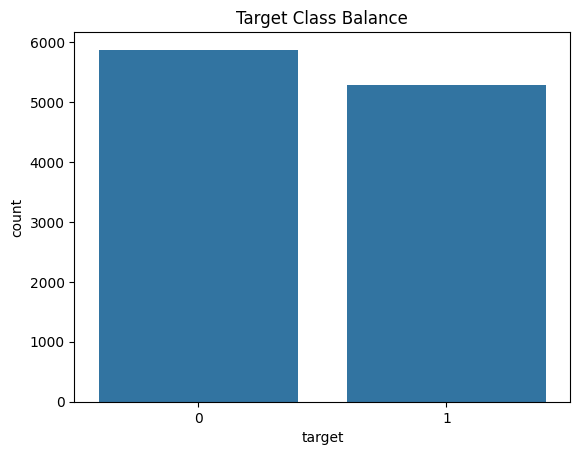

In [56]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x="target", data=df)
plt.title("Target Class Balance")
plt.show()

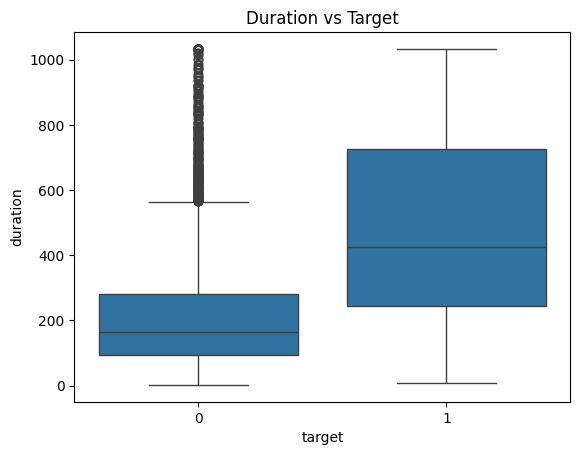

In [57]:
sns.boxplot(x="target", y="duration", data=df)
plt.title("Duration vs Target")
plt.show()

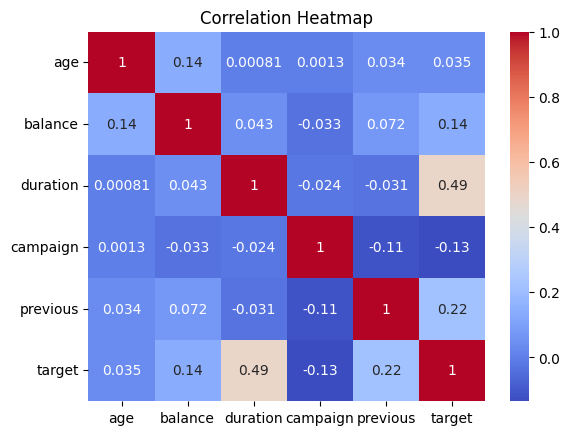

In [58]:
numeric_cols = ["age", "balance", "duration", "campaign", "previous", "target"]
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

DIVIDING TO CATEGORICAL AND NUMERIC COLUMNS

In [59]:
numeric_cols = ["age", "balance", "duration", "campaign", "previous", "was_contacted_before"]
categorical_cols = ["job", "marital", "education", "default", "housing", "loan",
                     "contact", "month", "poutcome"]

In [60]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
encoded = encoder.fit_transform(df[categorical_cols])

handle_unknown="ignore" — agar test ma'lumotida train'da bo'lmagan kategoriya chiqsa, xato bermay 0 qilib qo'yadi.

In [61]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaled = scaler.fit_transform(df[numeric_cols])

In [62]:
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer(transformers=[
    ("num", StandardScaler(), numeric_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)
])

TRAIN/TEST

In [63]:
X = df[numeric_cols + categorical_cols]
y = df["target"]

In [64]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

In [65]:
print(X_train.shape, X_test.shape)
print(y_train.value_counts(normalize=True))
print(y_test.value_counts(normalize=True))

(8929, 15) (2233, 15)
target
0    0.526151
1    0.473849
Name: proportion, dtype: float64
target
0    0.526198
1    0.473802
Name: proportion, dtype: float64


In [66]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000))
])

In [69]:
#model.fit(X_train, y_train)

In [68]:
model.score(X_train, y_train)

0.8292081980064957

In [70]:
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

In [71]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1:", f1_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_proba))

Accuracy: 0.8289296909986565
Precision: 0.8275193798449613
Recall: 0.8071833648393195
F1: 0.8172248803827751
ROC-AUC: 0.9072340425531914


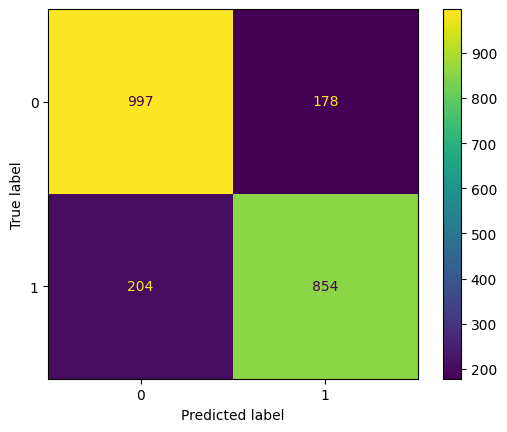

In [72]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(y_test, y_pred)